## Analyzing the Tennessee Education Achievement Data

This notebook is designed to accompany the DS 3100 lectures on data wrangling, exploratory data analysis, and visualization.

### Case-study question

> **What can the 2018 Tennessee education data tell us about differences in achievement across subjects and districts?**

You will progressively build an analysis rather than answer all questions at once.

## Imports

In [2]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## 0. The datasets

### Primary dataset: `tenn2018.csv`

The primary file contains 2018 Tennessee achievement results. Each row combines information about a district/school, student subgroup, subject, and achievement percentages, with 2017 baseline measures where available.

Important variables include:

- `district_number`, `district_name`
- `school_number`, `school_name`
- `subgroup`
- `overall_subject`
- `percent_below`, `percent_approaching`, `percent_on_track`, `percent_mastered`
- `percent_on_mastered`
- corresponding `_previous` measures

### Companion dataset: `tn_district_info.csv`

For our introductory join exercise, we will also use a **small lookup table derived from the primary 2018 district file**. It contains one row per district with the number of distinct schools and a simple district-size category. 
In a real analysis, this kind of information would typically come from a separate administrative source and it would often be necessary to strategically merge its information with the primary data for a more robust analysis.

Columns:

- `district_number`
- `district_name`
- `num_schools`
- `district_size`

Official Tennessee data-download information: https://www.tn.gov/education/districts/federal-programs-and-oversight/data/data-downloads.html

### The question guiding our analysis

> **How does student achievement vary across subjects, places, and student populations in Tennessee?**


In [2]:
# Read the two datasets
# Update the paths if your files are stored elsewhere.
ten <- read.csv("data/tenn2018.csv")
# Dimensions
nrow(ten)
ncol(ten)
head(ten, n=5)

[1] 121062

[1] 18

,district_number,district_name,school_number,school_name,year,subgroup,overall_subject,percent_below,percent_approaching,percent_on_track,percent_mastered,percent_on_mastered,baseline_year,percent_below_previous,percent_approaching_previous,percent_on_track_previous,percent_mastered_previous,percent_on_mastered_previous
,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0,State of Tennessee,0,,2018,All Students,ELA,19.5,47.7,28.1,4.7,32.8,2017,20.0,45.9,28.0,6.1,34.1
2,0,State of Tennessee,0,,2018,Black/Hispanic/Native,ELA,30.1,50.5,17.5,1.9,19.4,2017,30.9,49.2,17.6,2.3,19.9
3,0,State of Tennessee,0,,2018,Economically Disadvantaged,ELA,30.4,51.2,16.7,1.7,18.4,2017,31.5,49.6,16.9,2.0,18.9
4,0,State of Tennessee,0,,2018,English Learners,ELA,30.1,51.7,16.7,1.6,18.3,2017,34.3,49.1,15.1,1.5,16.6
5,0,State of Tennessee,0,,2018,Foster,ELA,33.9,50.0,14.4,1.8,16.2,NA,NA,NA,NA,NA,NA


In [3]:
district_info <- read.csv("data/tn_district_info.csv")
# Dimensions
nrow(district_info)
ncol(district_info)
head(district_info, n=5)

[1] 146

[1] 4

,district_number,district_name,num_schools,district_size
,<int>,<chr>,<int>,<chr>
1,10,Anderson County Schools,16,Medium (10-19 schools)
2,11,Clinton City School District,3,Small (1-9 schools)
3,12,Oak Ridge City Schools,7,Small (1-9 schools)
4,20,Bedford County Schools,14,Medium (10-19 schools)
5,30,Benton School System,6,Small (1-9 schools)


### 1. Getting to know the data

Before changing anything, inspect the structure of the primary dataset to understand the unit of observation.

::: {.callout-tip}

### Initial Thoughts

1. How many observations and variables are there?
2. What does one row represent?
3. Which variables identify the geographic unit, subgroup, and subject?
4. Which variables are numeric?
5. Which columns contain missing values?

:::

In [4]:
# Explore the structure
dim(ten)
colnames(ten)

[1] 121062     18

[1] "district_number"              "district_name"               
 [3] "school_number"                "school_name"                 
 [5] "year"                         "subgroup"                    
 [7] "overall_subject"              "percent_below"               
 [9] "percent_approaching"          "percent_on_track"            
[11] "percent_mastered"             "percent_on_mastered"         
[13] "baseline_year"                "percent_below_previous"      
[15] "percent_approaching_previous" "percent_on_track_previous"   
[17] "percent_mastered_previous"    "percent_on_mastered_previous"

### Some additional context

::: {.callout-note style="font-size:0.75em;"}
## Understanding the level of observation

The Tennessee dataset contains information reported at **multiple geographic levels**. The variables `district_number` and `school_number` help us distinguish between them.

| `district_number` | `school_number` | Represents |
|---|---|---|
| `0` | `0` | Statewide aggregate |
| `> 0` | `0` | District-level aggregate |
| `> 0` | `> 0` | Individual school |

For example, the dataset contains statewide observations where `district_number = 0` and `school_number = 0`, as well as district-level observations such as Anderson County Schools where `district_number = 10` and `school_number = 0`. 
:::

### Explore missingness

`ten.isna()` creates a Boolean DataFrame showing where values are missing. `.sum()` returns the sum of `TRUE` values over the requested axis which is set to 0 by default.

`.any()` checks whether each column contains at least one missing value, and `.sum()` counts how many columns satisfy that condition.

In [5]:
# Number of missing values in each column
ten %>% 
  is.na() %>% 
  colSums() %>% 
  enframe(name = "Column", value = "Missing_Count")

# Number of columns containing at least one missing value
sum(colSums(is.na(ten)) > 0)

Column,Missing_Count
<chr>,<dbl>
district_number,0
district_name,0
school_number,0
school_name,0
year,0
subgroup,0
overall_subject,0
percent_below,100266
percent_approaching,100266


[1] 11

## We need to define the population we want to analyze

The raw data combine multiple **subjects, student subgroups, and geographic levels**. A meaningful comparison requires us to narrow down the population we want to analyze.

::: {.callout-important style="font-size:0.75em;"}

### Your turn

Let's focus our analysis on the following variables:

- school-level observations only (`school_number > 0`);
- `subgroup == "All Students"` rather than specific demography subgroups;
- subjects `ELA` and `Math`;
- the variables needed to compare current and previous performance.

Keep the variables we need:

`district_number`, `district_name`, `school_number`, `school_name`, `overall_subject`, `percent_below`, `percent_on_mastered`, `percent_below_previous`, `percent_on_mastered_previous`.

:::

### Think before coding

Why would calculating a mean on the **entire raw dataset** be misleading?

> We would be mixing subjects, subgroups, and geographic levels. With the context that we have about how data is encoded here, the resulting estimates would be very misleading.


In [6]:
analysis_df <- ten %>%
  filter(
    school_number > 0,
    subgroup == "All Students",
    overall_subject %in% c("ELA", "Math")
  ) %>%
  select(
    district_number,
    district_name,
    school_number,
    school_name,
    overall_subject,
    percent_below,
    percent_on_mastered,
    percent_below_previous,
    percent_on_mastered_previous
  )

head(analysis_df, n=5)

,district_number,district_name,school_number,school_name,overall_subject,percent_below,percent_on_mastered,percent_below_previous,percent_on_mastered_previous
,<int>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,10,Anderson County Schools,2,Anderson County High School,ELA,NA,27.2,NA,32.5
2,10,Anderson County Schools,2,Anderson County High School,Math,NA,27.1,NA,26.7
3,10,Anderson County Schools,5,Andersonville Elementary,ELA,NA,32.9,23.0,36.8
4,10,Anderson County Schools,5,Andersonville Elementary,Math,18.4,46.7,22.4,44.1
5,10,Anderson County Schools,10,Briceville Elementary,ELA,NA,25.9,39.1,17.2


## Understanding the achievement measures

When tracking academic achievement, the state of Tennessee put student scores in one of four performance categories: below grade-level, approaching grade-level, on track, and mastered.

::: {.callout-note style="font-size:0.75em;"}

## Variables tracking student achievement

For our analysis, we will focus primarily on the following variables.

| Variable | Definition |
|---|---|
| `percent_below` | Percentage of students whose 2018 performance falls in the **Below** achievement category |
| `percent_on_mastered` | Percentage of students whose 2018 performance falls in the combined **On Track or Mastered** categories |
| `percent_below_previous` | Percentage of students in the **Below** category in the previous/baseline year |
| `percent_on_mastered_previous` | Percentage of students in the combined **On Track or Mastered** categories in the previous/baseline year |

The dataset identifies **2018** as the current reporting year and generally uses **2017** as the baseline year for these previous-year measures.
:::

### Possible interpretations

- **lower `percent_below`** generally represents a more favorable achievement outcome
- **higher `percent_on_mastered`** represents a higher proportion of students meeting the state's proficiency requirements


## 3. Create variables that help us compare achievement across years

The data include current and previous-year's achievement percentages.  Tracking the changes in these metrics across successive calendar years help us understand potential improvements or regression among different student groups.

::: {.callout-important style="font-size:0.75em;"}

### Your turn

Create two change measures:

- `change_below = percent_below - percent_below_previous`
- `change_on_mastered = percent_on_mastered - percent_on_mastered_previous`

Then inspect their distributions and answer:

- What does a **negative** `change_below` mean?
- What does a **positive** `change_on_mastered` mean?

:::

In [7]:
analysis_df <- analysis_df %>%
  mutate(
    change_below =
      percent_below - percent_below_previous,
    change_on_mastered =
      percent_on_mastered - percent_on_mastered_previous
  )

head(analysis_df, n=5)

,district_number,district_name,school_number,school_name,overall_subject,percent_below,percent_on_mastered,percent_below_previous,percent_on_mastered_previous,change_below,change_on_mastered
,<int>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,10,Anderson County Schools,2,Anderson County High School,ELA,NA,27.2,NA,32.5,NA,-5.3
2,10,Anderson County Schools,2,Anderson County High School,Math,NA,27.1,NA,26.7,NA,0.4
3,10,Anderson County Schools,5,Andersonville Elementary,ELA,NA,32.9,23.0,36.8,NA,-3.9
4,10,Anderson County Schools,5,Andersonville Elementary,Math,18.4,46.7,22.4,44.1,-4,2.6
5,10,Anderson County Schools,10,Briceville Elementary,ELA,NA,25.9,39.1,17.2,NA,8.7


### Lets recheck the status of missing values

::: {.callout-important style="font-size:0.75em;"}

### Your turn

Why does `change_below` have more missing values than `percent_below`?

:::

In [8]:
colSums(
  is.na(
    analysis_df[
      c(
        "percent_below",
        "percent_on_mastered",
        "change_below",
        "change_on_mastered"
      )
    ]
  )
)%>% enframe(name = "Column", value = "Missing_Count")

Column,Missing_Count
<chr>,<dbl>
percent_below,2105
percent_on_mastered,228
change_below,2487
change_on_mastered,292


Nonetheless it is a good idea to remove these missing values before generating grouped summaries because we know missing values can be contagious to downstream operations.

In [9]:
cat("Number of rows before dropping missing values:", nrow(analysis_df),"\n")

analysis_df_wo_missing <- analysis_df %>%
  filter(
    !is.na(percent_below),
    !is.na(percent_on_mastered),
    !is.na(change_below),
    !is.na(change_on_mastered)
  )

cat("Number of rows after dropping missing values:", nrow(analysis_df_wo_missing))

Number of rows before dropping missing values: 3498 
Number of rows after dropping missing values: 1011

## 4. Group and summarize

Now lets answer our first analytical question:

> **How do achievement outcomes differ between ELA and Math?**

### Lets recheck the status of missing values

::: {.callout-important style="font-size:0.75em;"}

### Your turn

Calculate, by subject:

- number of available observations;
- mean `percent_below`;
- median `percent_below`;
- mean `percent_on_mastered`;
- mean `change_below`.

Then inspect whether the means and medians tell a similar story.

:::

In [10]:
subject_summary <- analysis_df_wo_missing %>%
  group_by(overall_subject) %>%
  summarize(
    n_observations = n(),
    mean_percent_below =
      mean(percent_below),
    median_percent_below =
      median(percent_below),
    mean_change_below =
      mean(change_below)
  )

subject_summary

overall_subject,n_observations,mean_percent_below,median_percent_below,mean_change_below
<chr>,<int>,<dbl>,<dbl>,<dbl>
ELA,308,12.3487,12.05,-0.8103896
Math,703,21.5064,20.70,2.1762447


## 5. Why might we need another dataset?

Suppose we now ask:

> **Do achievement outcomes differ across small, medium, and large districts?**

Look back at the columns in `analysis`.

**Can the primary dataset answer this question directly?**

No: it identifies the district, but it does not contain information regarding district-size.

This is a common reason for a join:

> **The question requires information that lives in another dataset.**

Our companion `tn_district_info.csv` provides that additional information.

## 6. Join the district information

Usually joins happen on a common key shared across datasets. The two tables here share a district identifier:

- `analysis_df_wo_missing`: `district_number`, `district_name`
- `district_info`: `district_number`, `district_name`

::: {.callout-important style="font-size:0.75em;"}

### Your turn

1. Inspect `district_info`.
2. Check whether `district_number` is unique there.
3. Decide which table should be the **left** table.
4. Perform a **left join/merge** so that every achievement observation is retained.
5. Check the number of rows before and after the join.
6. Check whether any observations failed to find district information.

:::

In [11]:
joined <- analysis_df_wo_missing %>%
  left_join(
    district_info,
    by = c(
      "district_number",
      "district_name"
    ),
    relationship = "many-to-one"
  )

In [12]:
head(joined, n=2)

,district_number,district_name,school_number,school_name,overall_subject,percent_below,percent_on_mastered,percent_below_previous,percent_on_mastered_previous,change_below,change_on_mastered,num_schools,district_size
,<int>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
1,10,Anderson County Schools,5,Andersonville Elementary,Math,18.4,46.7,22.4,44.1,-4.0,2.6,16,Medium (10-19 schools)
2,10,Anderson County Schools,70,Norris Elementary,ELA,10.5,49.2,14.6,49.2,-4.1,0.0,16,Medium (10-19 schools)


In [13]:
# Number of rows before and after
nrow(analysis_df_wo_missing)
nrow(joined)

# Checking whether district information could be missing after the join
sum(is.na(joined$district_size))

[1] 1011

[1] 1011

[1] 0

## 7. Post-join wrangling

Now that the district-size information is available, use it to investigate the new question.

::: {.callout-important style="font-size:0.75em;"}

### Your turn

1. Check the number of observations in each `district_size` category.
2. Compare mean `percent_below` across district-size categories.
3. Compare mean `change_below` across district-size categories.
4. Identify any categories with noticeably different results.

:::

Do not interpret differences as **causal**. At this stage we are describing patterns in the data.

In [14]:
# Checking the number of observations in each district_size category.
joined %>%
  count(district_size)

district_size,n
<chr>,<int>
Large (20+ schools),445
Medium (10-19 schools),256
Small (1-9 schools),310


In [15]:
size_summary <- joined %>%
  group_by(district_size) %>%
  summarize(
    n_observations = n(),
    mean_percent_below =
      mean(percent_below, na.rm = TRUE),
    mean_change_below =
      mean(change_below, na.rm = TRUE)
  )

size_summary

district_size,n_observations,mean_percent_below,mean_change_below
<chr>,<int>,<dbl>,<dbl>
Large (20+ schools),445,18.64584,1.299775
Medium (10-19 schools),256,19.02930,1.148828
Small (1-9 schools),310,18.55968,1.315484


## EDA and Visualization

Now you will be asked to generate some visualizations to further solidify your understanding of the data at your disposal before more informed decisions.

::: {.callout-note style="font-size:0.75em;"}

Some <span style="color:#3567B0;">**important instructions**</span> that apply to every visualization you generate henceforth.

1. A title, all axes must have labels with a consistent font and sizing.
2. If needed, the plot must have proper legends.
3. To be thematically consistent choose the same set of colours to fill your plots and to outline them across all visualizations.

:::

## 8. Additional EDA after the join

A summary tells us where the **center** is, but not how the observations are distributed.

::: {.callout-important style="font-size:0.75em;"}

### Your turn

Use the joined data to investigate:

- How spread out is `percent_below` within each district-size category?
- Are there unusual observations?
- Does the relationship between district size and achievement look consistent across ELA and Math?

:::

Useful questions to keep asking during EDA:

> **What is typical? What is variable? What is unusual? What is different across groups?**

## 9. Visualization 1: Distribution by subject

Create a visualization comparing the distributions of `percent_below` for **ELA versus Math**.

A boxplot is one likely choice because it shows the median, spread, and potential outliers. It marks all the important summary statistics. What else could you plot in this scenario?

::: {.callout-important style="font-size:0.75em;"}

### Your turn

- In a markdown cell in 1–2 sentences explain the rationale behind the choice of your plot, describing the nature of your problem statement and your variables and the appropriateness of the plot in regard to this.
- Write code and generate your plot.

:::

In [ ]:
# Starter: create a side-by-side boxplot using ggplot2.

plot_data <- analysis_df_wo_missing %>%
  filter(overall_subject %in% c("ELA", "Math"))

# Complete the ggplot specification.


## 10. Visualization 2: Does achievement differ by district size?

Now use the variable that became available **only after the join** to investigate whether the distribution of achievement differs across districts of different sizes.

Create a **series of three visualizations**, one for each district-size group:

- Small districts
- Medium districts
- Large districts

::: {.callout-important style="font-size:0.75em;"}

### Your turn

For each district-size group, show the distribution of `percent_below` using **two layers**:

1. a **density plot** to show the overall shape of the distribution;
2. a **boxplot** to show the median, quartiles, spread, and potential outliers.

Your three plots should use the **same axis limits and general styling** so that the distributions can be compared directly.

Use **faceting** to display them together.

Then answer in a few sentences:

> **Does district size appear to be associated with differences in the distribution of `percent_below`? What features of the visualizations support your answer?**

:::

::: {.callout-tip}

### What should you look for?

Compare the three distributions rather than focusing only on their averages.

- Where is the **center** of each distribution?
- Which district-size group shows the greatest **spread**?
- Do the distributions differ in **shape or skewness**?
- Are there potential **outliers**?
- Do the density plot and boxplot reveal different aspects of the same distribution?

**Remember**: this is an **exploratory** comparison. At this point we should only describe the patterns we observe. Do not interpret an apparent difference in your data as evidence that district size *causes* differences in achievement.

:::

In [ ]:
# Starter: density + boxplot faceted by district size.

plot_data <- joined %>%
  filter(!is.na(district_size))

# Complete the layered ggplot specification.


## 11. Visualization 3: How has achievement changed?

We created `change_below` before the join. This variable measures how
`percent_below` changed relative to the previous year.

::: {.callout-important style="font-size:0.75em;"}

### Your turn

Create a **histogram of `change_below`** with **a vertical reference line at 0**.

Use the histogram to examine:

- whether most changes are close to zero;
- whether increases and decreases are balanced;
- whether there are unusually large changes in either direction.

Remember how to interpret the changes correctly:

- `change_below < 0` → the percentage below decreased;
- `change_below > 0` → the percentage below increased.

Then answer in a few sentences:

> **What does the distribution of year-to-year changes suggest about how much achievement varies from one year to the next?**

:::

::: {.callout-tip style="font-size:0.75em;"}

You can use **Generative AI** (or your own investigation into `ggplot2`) to look up how to insert a vertical reference line within the same plot as the histogram.<br> 
**Remember**, that the plot still needs to fulfill the general styling and thematic guidelines laid out earlier.
Do not forget to log your AI Usage on the discussion forum for this activity.

:::

In [ ]:
## necessary data wrangling
plot_data <- analysis_df_wo_missing %>%
  filter(!is.na(change_below))
# ...

## code for plot

## 12. Visualization 4: Achievement, district size, and subject

Now bring together the three variables:

- `percent_below`
- `percent_on_mastered`
- `overall_subject`: *limit only to Math and Social Science*

and use the `district-size` groups created by the join.

::: {.callout-important style="font-size:0.75em;"}

### Your turn

Create a **scatterplot** with:

- `percent_below` on the x-axis;
- `percent_on_mastered` on the y-axis;
- **color** representing `overall_subject`;
- separate panels (**faceting**) for Small, Medium, and Large districts.

Use the same axis scales across all panels so that the relationships can be compared directly.

Then, in a few sentences answer:

> **Does the relationship between `percent_below` and `percent_on_mastered` appear to change with district size or subject?**

:::

::: {.callout-tip style="font-size:0.75em;"}

Time to summarize the patterns you see by considering the following:

- Does the relationship between the two achievement measures appear similar across district sizes?
- Does the relationship differ by subject?
- Are there any unusual observations or groups?

:::

In [ ]:
# Starter: scatterplot with color and faceting.

## necessary data wrangling
plot_data <- joined %>%
  filter(
    overall_subject %in% c("Math", "Social Science"),
    !is.na(percent_below),
    !is.na(percent_on_mastered),
    !is.na(district_size)
  )

## code for plot


## 13. Final case-study question

You now have enough tools to investigate the broader question:

> **What can the 2018 Tennessee education data tell us about differences in achievement across subjects and districts?**

::: {.callout-important style="font-size:0.75em;"}

### Build a short analysis

Use the joined dataset to produce a small analysis with:

1. a clearly stated analytical question;
2. appropriate filtering;
3. at least one newly created variable;
4. at least one grouped summary;
5. at least one visualization;
6. a short interpretation.

Your question should be **descriptive**, not causal.

:::

## 14. Final reflection

In a markdown cell, write a **3–5 sentence conclusion** that answers your analytical question.

::: {.callout-tip style="font-size:0.75em;"}

Your conclusion should:

- state the main pattern you found;
- refer to evidence from your summary or visualization;
- distinguish between **description and causal explanation**; and
- mention one limitation of the analysis.

:::

Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”


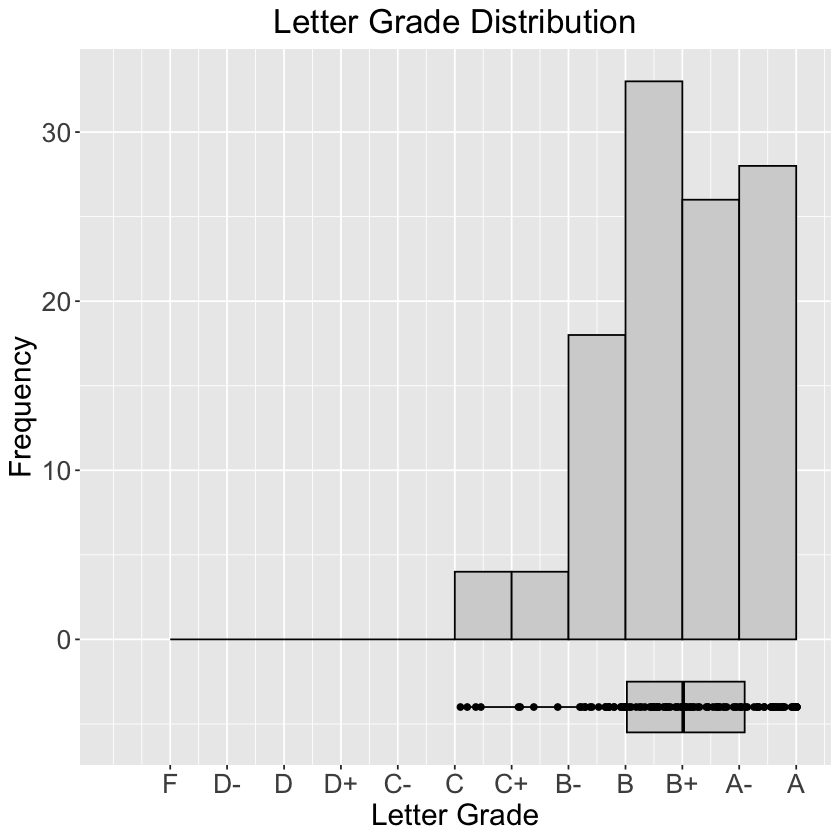

In [ ]:
load("data/PluckData.RData")

# let's make a custom scale with breaks that align with our letter grade encoding
# sequence and round to get appropriate breaks
grade_breaks <- round(seq(0.33, 4.00, 1/3), 3)
x_axis <- scale_x_continuous(
    name = "Letter Grade",
    limits = c(0.00, 4.00), 
    breaks = grade_breaks,
    labels = c("F", "D-", "D", "D+", "C-", "C", "C+", "B-", "B", "B+", "A-", "A")
  )

# theme customizes the non-data components of your plot
my_theme <- theme(
    axis.text = element_text(size = 16),
    # axis.text.x = element_text(angle = 45, hjust = 1),
    axis.title = element_text(size = 18),
    plot.title = element_text(
    size = 20,
    hjust = 0.50
    )
  )

# Create histogram as *first* layer
ggplot(data = dataset, aes(x = GPA)) +
  geom_histogram( # first layer
    breaks = grade_breaks,
    color = "black", fill = "lightgrey"
  )+
  geom_boxplot( # second layer
    color = "black", fill = "lightgrey",
    aes(y = -4), width = 3
  )+ 
  geom_point( # third layer
    aes(y = -4), color = "black" # notice we used `color` rather than `fill`
  ) + x_axis + my_theme +
  labs(y = "Frequency", title = "Letter Grade Distribution")

In [4]:
dataset$GPA

[1]   2.93   2.98   3.57   3.98   3.54   3.22   4.00   2.90   3.81   3.33
 [11]   3.33   3.02 999.00   2.76   2.90   3.14   2.73   3.53   3.15   3.24
 [21]   2.37   2.12   3.87   3.09   2.97   3.85   3.53   3.77   3.48   3.81
 [31]   3.64   3.67   3.85   3.18   3.88   4.00   3.98   3.71   2.88 999.00
 [41]   2.07   2.60   3.18   2.84   3.48   3.91   3.39   2.15   3.51   2.74
 [51]   3.58   4.00   3.90   4.00   3.03   2.46   3.38   2.99   2.97   4.00
 [61]   3.06   2.79   2.76   3.00   3.26   3.16   3.19   3.77   3.54 999.00
 [71]   3.29   3.89   3.97   3.16   3.30   3.25   3.43   3.35   3.00   3.23
 [81]   3.78   3.00   3.65   3.19   3.35   3.37   3.32   3.34   3.42   3.40
 [91]   3.16   3.55   2.80   3.30   2.88   3.59   3.63   3.93   3.24   3.70
[101]   3.67    NaN   2.03   3.77   3.35   3.92   3.86   2.38   3.47   2.93
[111]   3.00   3.92   3.11   3.75   3.87   3.19   2.90   3.15   3.08   3.54
[121]   3.68   3.98

In [9]:
grade_breaks <- round(
  seq(0.333, 4.00, 1/3),
  3
)

grade_labels <- c(
  "F", "D-", "D", "D+",
  "C-", "C", "C+",
  "B-", "B", "B+",
  "A-", "A"
)

data.frame(
  GPA = grade_breaks,
  Letter_Grade = grade_labels
)

GPA,Letter_Grade
<dbl>,<chr>
0.333,F
0.666,D-
1.000,D
1.333,D+
1.666,C-
2.000,C
2.333,C+
2.666,B-
3.000,B
